In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
# Training configuration

NUM_FRAMES = 16
BATCH_SIZE = 8
NUM_EPOCHS = 15

# Learning rates
CNN_LEARNING_RATE = 1e-5
LSTM_LEARNING_RATE = 1e-3

NUM_CLASSES = 5
HIDDEN_SIZE = 256
NUM_LAYERS = 2

CLASS_NAMES = [
    "Smash",
    "Clear",
    "Net Shot",
    "Drop",
    "Drive"
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# New checkpoint for fine-tuning experiment
BEST_MODEL_PATH = "/content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth"

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Frames:", NUM_FRAMES)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("CNN learning rate:", CNN_LEARNING_RATE)
print("LSTM learning rate:", LSTM_LEARNING_RATE)
print("Checkpoint:", BEST_MODEL_PATH)

Device: cuda
GPU: Tesla T4
Frames: 16
Batch size: 8
Epochs: 15
CNN learning rate: 1e-05
LSTM learning rate: 0.001
Checkpoint: /content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/datasets2"

print("Dataset path:", DATASET_PATH)
print("\nContents:")

for item in os.listdir(DATASET_PATH):
    print(" -", item)

Dataset path: /content/drive/MyDrive/datasets2

Contents:
 - CLEAR
 - SMASH
 - NET SHOT
 - DROP
 - DRIVE


In [ ]:
#Count all videos inside the nested folders

import os

classes = [
    "SMASH",
    "CLEAR",
    "NET SHOT",
    "DROP",
    "DRIVE"
]

video_extensions = (".mp4", ".avi", ".mov", ".mkv")

print("VIDEO COUNT")
print("=" * 40)

total = 0

for class_name in classes:
    class_folder = os.path.join(DATASET_PATH, class_name)

    videos = []

    for root, dirs, files in os.walk(class_folder):
        for file in files:
            if file.lower().endswith(video_extensions):
                videos.append(os.path.join(root, file))

    print(f"{class_name}: {len(videos)} videos")
    total += len(videos)

print("=" * 40)
print(f"TOTAL: {total} videos")

VIDEO COUNT
SMASH: 700 videos
CLEAR: 700 videos
NET SHOT: 705 videos
DROP: 700 videos
DRIVE: 660 videos
TOTAL: 3465 videos


In [ ]:
video_paths = []
labels = []

class_to_label = {
    "SMASH": 0,
    "CLEAR": 1,
    "NET SHOT": 2,
    "DROP": 3,
    "DRIVE": 4
}

video_extensions = (".mp4", ".avi", ".mov", ".mkv")

for class_name, label in class_to_label.items():

    class_folder = os.path.join(DATASET_PATH, class_name)

    for root, dirs, files in os.walk(class_folder):

        for file in files:

            if file.lower().endswith(video_extensions):

                video_paths.append(os.path.join(root, file))
                labels.append(label)

print("Total videos:", len(video_paths))
print("Total labels:", len(labels))

print("\nClass distribution:")
for class_name, label in class_to_label.items():
    print(f"{class_name}: {labels.count(label)}")

Total videos: 3465
Total labels: 3465

Class distribution:
SMASH: 700
CLEAR: 700
NET SHOT: 705
DROP: 700
DRIVE: 660


In [ ]:
# Train / Validation / Test split

X_train, X_temp, y_train, y_temp = train_test_split(
    video_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Dataset split:")
print("------------------------")
print("Training videos:  ", len(X_train))
print("Validation videos:", len(X_val))
print("Test videos:      ", len(X_test))
print("Total videos:     ", len(X_train) + len(X_val) + len(X_test))

Dataset split:
------------------------
Training videos:   2425
Validation videos: 520
Test videos:       520
Total videos:      3465


In [ ]:
class BadmintonDataset(torch.utils.data.Dataset):

    def __init__(self, video_paths, labels, num_frames=16):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):

        video_path = self.video_paths[idx]
        label = self.labels[idx]

        cap = cv2.VideoCapture(video_path)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Select exactly 16 evenly spaced frames
        frame_indices = np.linspace(
            0,
            total_frames - 1,
            self.num_frames
        ).astype(int)

        frames = []

        for frame_idx in frame_indices:

            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

            ret, frame = cap.read()

            if ret:
                frame = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )

                frame = Image.fromarray(frame)
                frame = self.transform(frame)

                frames.append(frame)

            else:
                # Black frame if reading fails
                black_frame = Image.fromarray(
                    np.zeros((224, 224, 3), dtype=np.uint8)
                )

                black_frame = self.transform(black_frame)

                frames.append(black_frame)

        cap.release()

        frames = torch.stack(frames)

        return frames, torch.tensor(label, dtype=torch.long)

In [ ]:
# Create Dataset objects

train_dataset = BadmintonDataset(
    X_train,
    y_train,
    num_frames=NUM_FRAMES
)

val_dataset = BadmintonDataset(
    X_val,
    y_val,
    num_frames=NUM_FRAMES
)

test_dataset = BadmintonDataset(
    X_test,
    y_test,
    num_frames=NUM_FRAMES
)


# Create DataLoaders

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


print("DataLoaders created!")
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created!
Train batches: 304
Validation batches: 65
Test batches: 65


In [ ]:
# Test one training batch

frames, labels = next(iter(train_loader))

print("Frames shape:", frames.shape)
print("Labels shape:", labels.shape)

print("Frames dtype:", frames.dtype)
print("Labels:", labels)

Frames shape: torch.Size([8, 16, 3, 224, 224])
Labels shape: torch.Size([8])
Frames dtype: torch.float32
Labels: tensor([3, 2, 4, 4, 0, 1, 3, 0])


In [ ]:
class BadmintonCNNLSTM(nn.Module):

    def __init__(
        self,
        num_classes=5,
        hidden_size=256,
        num_layers=2
    ):
        super().__init__()

        # Pretrained ResNet18
        self.cnn = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # Remove ImageNet classifier
        self.cnn.fc = nn.Identity()

        # Fine-tune the entire CNN
        for param in self.cnn.parameters():
            param.requires_grad = True

        # LSTM
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):

        batch_size, seq_len, C, H, W = x.size()

        # Combine batch and frame dimensions
        x = x.view(
            batch_size * seq_len,
            C,
            H,
            W
        )

        # CNN feature extraction
        features = self.cnn(x)

        # Restore sequence dimension
        features = features.view(
            batch_size,
            seq_len,
            -1
        )

        # Temporal modeling
        lstm_out, _ = self.lstm(features)

        # Last frame's LSTM output
        last_output = lstm_out[:, -1, :]

        # Classification
        output = self.classifier(last_output)

        return output

In [ ]:
# Create model
model = BadmintonCNNLSTM(
    num_classes=NUM_CLASSES,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
)

# Move model to GPU
model = model.to(DEVICE)

print("Model device:", next(model.parameters()).device)

# Count trainable parameters
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 92.2MB/s]


Model device: cuda:0
Total parameters: 12492613
Trainable parameters: 12492613


In [ ]:
# Test one batch through the model on GPU

frames, labels = next(iter(train_loader))

frames = frames.to(DEVICE)
labels = labels.to(DEVICE)

with torch.no_grad():
    outputs = model(frames)

print("Input shape:", frames.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("GPU:", torch.cuda.get_device_name(0))

Input shape: torch.Size([8, 16, 3, 224, 224])
Output shape: torch.Size([8, 5])
Labels shape: torch.Size([8])
GPU: Tesla T4


In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()


# Separate learning rates
# CNN gets a smaller learning rate because it is
# already pretrained on ImageNet.
optimizer = torch.optim.Adam([
    {
        "params": model.cnn.parameters(),
        "lr": CNN_LEARNING_RATE
    },
    {
        "params": model.lstm.parameters(),
        "lr": LSTM_LEARNING_RATE
    },
    {
        "params": model.classifier.parameters(),
        "lr": LSTM_LEARNING_RATE
    }
])


print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("CNN learning rate:", CNN_LEARNING_RATE)
print("LSTM learning rate:", LSTM_LEARNING_RATE)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0

Parameter Group 2
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
CNN learning rate: 1e-05
LSTM learning rate: 0.001


In [ ]:
# Recreate DataLoaders with 2 workers

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("DataLoaders recreated successfully!")
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders recreated successfully!
Train batches: 304
Validation batches: 65
Test batches: 65


In [ ]:
frames, labels = next(iter(train_loader))

print("Frames shape:", frames.shape)
print("Labels shape:", labels.shape)
print("Frames dtype:", frames.dtype)

Frames shape: torch.Size([8, 16, 3, 224, 224])
Labels shape: torch.Size([8])
Frames dtype: torch.float32


In [ ]:
import time

best_val_f1 = 0.0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

val_f1_scores = []


for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # =========================
    # TRAIN
    # =========================

    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for frames, labels in train_loader:

        frames = frames.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(frames)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        train_total += labels.size(0)

        train_correct += (
            predictions == labels
        ).sum().item()


    train_loss = (
        running_loss / len(train_loader)
    )

    train_acc = (
        train_correct / train_total
    )


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_running_loss = 0.0

    val_correct = 0
    val_total = 0

    all_val_predictions = []
    all_val_labels = []


    with torch.no_grad():

        for frames, labels in val_loader:

            frames = frames.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(frames)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += loss.item()

            predictions = outputs.argmax(
                dim=1
            )

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()

            all_val_predictions.extend(
                predictions.cpu().numpy()
            )

            all_val_labels.extend(
                labels.cpu().numpy()
            )


    val_loss = (
        val_running_loss / len(val_loader)
    )

    val_acc = (
        val_correct / val_total
    )

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro"
    )


    # =========================
    # SAVE BEST MODEL
    # =========================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_acc,
                "val_f1": val_f1
            },
            BEST_MODEL_PATH
        )

        status = " ⭐ BEST MODEL SAVED"

    else:

        status = ""


    # =========================
    # STORE HISTORY
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    val_f1_scores.append(val_f1)


    # =========================
    # TIME
    # =========================

    epoch_time = (
        time.time() - start_time
    ) / 60


    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Val F1: {val_f1:.4f} "
        f"| Time: {epoch_time:.2f} min"
        f"{status}"
    )


print("\n==============================")
print("TRAINING COMPLETE")
print("==============================")

print(
    f"Best validation F1: "
    f"{best_val_f1:.4f}"
)

print(
    "Best model saved at:"
)

print(BEST_MODEL_PATH)

Epoch [1/15] | Train Loss: 1.2472 | Train Acc: 0.4491 | Val Loss: 0.9976 | Val Acc: 0.5519 | Val F1: 0.5097 | Time: 21.54 min ⭐ BEST MODEL SAVED
Epoch [2/15] | Train Loss: 0.9335 | Train Acc: 0.5847 | Val Loss: 0.8629 | Val Acc: 0.5981 | Val F1: 0.6013 | Time: 15.33 min ⭐ BEST MODEL SAVED
Epoch [3/15] | Train Loss: 0.8502 | Train Acc: 0.6070 | Val Loss: 0.8148 | Val Acc: 0.6423 | Val F1: 0.6407 | Time: 15.84 min ⭐ BEST MODEL SAVED
Epoch [4/15] | Train Loss: 0.7265 | Train Acc: 0.6742 | Val Loss: 0.7385 | Val Acc: 0.7269 | Val F1: 0.7085 | Time: 16.14 min ⭐ BEST MODEL SAVED
Epoch [5/15] | Train Loss: 0.6330 | Train Acc: 0.7410 | Val Loss: 0.6808 | Val Acc: 0.7558 | Val F1: 0.7354 | Time: 16.57 min ⭐ BEST MODEL SAVED
Epoch [6/15] | Train Loss: 0.5665 | Train Acc: 0.7724 | Val Loss: 0.6547 | Val Acc: 0.7596 | Val F1: 0.7491 | Time: 17.10 min ⭐ BEST MODEL SAVED
Epoch [7/15] | Train Loss: 0.4994 | Train Acc: 0.7979 | Val Loss: 0.6515 | Val Acc: 0.7577 | Val F1: 0.7484 | Time: 15.42 min
Epoc

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import torch

BEST_MODEL_PATH = "/content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth"

print("Checkpoint exists:", os.path.exists(BEST_MODEL_PATH))

if os.path.exists(BEST_MODEL_PATH):
    checkpoint = torch.load(
        BEST_MODEL_PATH,
        map_location="cpu",
        weights_only=True
    )

    print("Checkpoint keys:", checkpoint.keys())
    print("Saved epoch:", checkpoint["epoch"])
    print("Saved validation accuracy:", checkpoint["val_accuracy"])
    print("Saved validation F1:", checkpoint["val_f1"])

Mounted at /content/drive
Checkpoint exists: True
Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_accuracy', 'val_f1'])
Saved epoch: 10
Saved validation accuracy: 0.7980769230769231
Saved validation F1: 0.7938373746416151


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# ==========================================
# CONFIGURATION
# ==========================================

NUM_CLASSES = 5
HIDDEN_SIZE = 256
NUM_LAYERS = 2

CNN_LEARNING_RATE = 1e-5
LSTM_LEARNING_RATE = 1e-3

NUM_EPOCHS = 15

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "best_badminton_cnn_lstm_model2.pth"
)

# ==========================================
# DEVICE
# ==========================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ==========================================
# MODEL
# ==========================================

class BadmintonCNNLSTM(nn.Module):

    def __init__(
        self,
        num_classes=5,
        hidden_size=256,
        num_layers=2
    ):
        super().__init__()

        self.cnn = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        self.cnn.fc = nn.Identity()

        for param in self.cnn.parameters():
            param.requires_grad = True

        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(
                hidden_size,
                num_classes
            )
        )

    def forward(self, x):

        batch_size, seq_len, C, H, W = x.size()

        x = x.view(
            batch_size * seq_len,
            C,
            H,
            W
        )

        features = self.cnn(x)

        features = features.view(
            batch_size,
            seq_len,
            -1
        )

        lstm_out, _ = self.lstm(features)

        last_output = lstm_out[:, -1, :]

        return self.classifier(last_output)


# ==========================================
# CREATE MODEL
# ==========================================

model = BadmintonCNNLSTM(
    num_classes=NUM_CLASSES,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(DEVICE)

print("Model created successfully")
print("Model device:", next(model.parameters()).device)

Device: cuda
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


Model created successfully
Model device: cuda:0


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
BEST_MODEL_PATH = "/content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth"

print("Checkpoint exists:", os.path.exists(BEST_MODEL_PATH))
print("Checkpoint:", BEST_MODEL_PATH)

Checkpoint exists: True
Checkpoint: /content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth


In [ ]:
# ==========================================
# LOAD TRAINED CHECKPOINT
# ==========================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("==============================")
print("TRAINED MODEL LOADED")
print("==============================")

print("Saved epoch:", checkpoint["epoch"])

print(
    "Validation Accuracy:",
    f"{checkpoint['val_accuracy'] * 100:.2f}%"
)

print(
    "Validation F1:",
    f"{checkpoint['val_f1'] * 100:.2f}%"
)

TRAINED MODEL LOADED
Saved epoch: 10
Validation Accuracy: 79.81%
Validation F1: 79.38%


In [ ]:
# ==========================================
# FINE-TUNING EPOCHS 11-15
# REDUCED LEARNING RATES
# ==========================================

CNN_FINE_TUNE_LR = 3e-6
LSTM_FINE_TUNE_LR = 3e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    [
        {
            "params": model.cnn.parameters(),
            "lr": CNN_FINE_TUNE_LR
        },
        {
            "params": model.lstm.parameters(),
            "lr": LSTM_FINE_TUNE_LR
        },
        {
            "params": model.classifier.parameters(),
            "lr": LSTM_FINE_TUNE_LR
        }
    ]
)

# IMPORTANT:
# Load the optimizer state from Epoch 10 is NOT ideal here,
# because we're intentionally changing the learning rates.

best_val_f1 = checkpoint["val_f1"]

print("Fine-tuning optimizer ready")
print("CNN LR:", CNN_FINE_TUNE_LR)
print("LSTM LR:", LSTM_FINE_TUNE_LR)
print("Starting best Val F1:", best_val_f1)

Fine-tuning optimizer ready
CNN LR: 3e-06
LSTM LR: 0.0003
Starting best Val F1: 0.7938373746416151


In [ ]:
# ==========================================
# RECREATE DATASET CLASS
# ==========================================

import os
import cv2
import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


class BadmintonDataset(Dataset):

    def __init__(self, video_paths, labels, num_frames=16):

        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):

        video_path = self.video_paths[idx]
        label = self.labels[idx]

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        frame_indices = np.linspace(
            0,
            total_frames - 1,
            self.num_frames
        ).astype(int)

        frames = []

        for frame_idx in frame_indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                frame_idx
            )

            ret, frame = cap.read()

            if ret:

                frame = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )

                frame = Image.fromarray(frame)

                frame = self.transform(frame)

                frames.append(frame)

            else:

                black_frame = Image.fromarray(
                    np.zeros(
                        (224, 224, 3),
                        dtype=np.uint8
                    )
                )

                black_frame = self.transform(
                    black_frame
                )

                frames.append(black_frame)

        cap.release()

        frames = torch.stack(frames)

        return (
            frames,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )


print("Dataset class recreated.")

Dataset class recreated.


In [ ]:
# ==========================================
# RECREATE EXACT DATA SPLIT
# ==========================================

import os
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

DATASET_PATH = "/content/drive/MyDrive/datasets2"

class_to_label = {
    "SMASH": 0,
    "CLEAR": 1,
    "NET SHOT": 2,
    "DROP": 3,
    "DRIVE": 4
}

CLASS_NAMES = [
    "Smash",
    "Clear",
    "Net Shot",
    "Drop",
    "Drive"
]

video_extensions = (".mp4", ".avi", ".mov", ".mkv")

video_paths = []
labels = []

# ==========================================
# COLLECT VIDEOS
# ==========================================

for class_name, label in class_to_label.items():

    class_folder = os.path.join(
        DATASET_PATH,
        class_name
    )

    for root, dirs, files in os.walk(class_folder):

        for file in files:

            if file.lower().endswith(video_extensions):

                video_paths.append(
                    os.path.join(root, file)
                )

                labels.append(label)


print("Total videos:", len(video_paths))


# ==========================================
# EXACT SAME SPLIT AS BEFORE
# ==========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    video_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print()
print("================================")
print("DATASET SPLIT")
print("================================")
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))


# ==========================================
# CREATE TEST DATASET
# ==========================================

test_dataset = BadmintonDataset(
    X_test,
    y_test,
    num_frames=16
)


# ==========================================
# TEST DATALOADER
# ==========================================

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print()
print("Test batches:", len(test_loader))


# ==========================================
# LOAD BEST TRAINED CHECKPOINT
# ==========================================

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "best_badminton_cnn_lstm_model2.pth"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

# IMPORTANT FOR TESTING
model.eval()


# ==========================================
# TEST
# ==========================================

all_predictions = []
all_labels = []

test_loss = 0.0

criterion = nn.CrossEntropyLoss()

with torch.no_grad():

    for frames, labels_batch in test_loader:

        frames = frames.to(
            DEVICE,
            non_blocking=True
        )

        labels_batch = labels_batch.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(frames)

        loss = criterion(
            outputs,
            labels_batch
        )

        test_loss += loss.item()

        predictions = outputs.argmax(
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels_batch.cpu().numpy()
        )


# ==========================================
# METRICS
# ==========================================

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

avg_test_loss = (
    test_loss / len(test_loader)
)


# ==========================================
# RESULTS
# ==========================================

print()
print("==========================================")
print("FINAL TEST RESULTS")
print("==========================================")

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

print(
    f"Test Macro F1: {test_f1 * 100:.2f}%"
)

print(
    f"Test Loss: {avg_test_loss:.4f}"
)


# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print()
print("==========================================")
print("CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)


# ==========================================
# CONFUSION MATRIX
# ==========================================

print()
print("==========================================")
print("CONFUSION MATRIX")
print("==========================================")

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

Total videos: 3465

DATASET SPLIT
Training: 2425
Validation: 520
Test: 520

Test batches: 65

FINAL TEST RESULTS
Test Accuracy: 76.15%
Test Macro F1: 75.82%
Test Loss: 0.7261

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Smash     0.7143    0.8095    0.7589       105
       Clear     0.6400    0.7619    0.6957       105
    Net Shot     0.9238    0.9151    0.9194       106
        Drop     0.6316    0.4571    0.5304       105
       Drive     0.9053    0.8687    0.8866        99

    accuracy                         0.7615       520
   macro avg     0.7630    0.7625    0.7582       520
weighted avg     0.7617    0.7615    0.7570       520


CONFUSION MATRIX
[[85  6  0 12  2]
 [ 6 80  2 15  2]
 [ 1  5 97  1  2]
 [25 29  0 48  3]
 [ 2  5  6  0 86]]


In [ ]:
# ==========================================
# AUGMENTED BADMINTON DATASET
# ==========================================

class BadmintonDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        video_paths,
        labels,
        num_frames=16,
        training=False
    ):

        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.training = training

        # Training augmentation
        if training:

            self.transform = transforms.Compose([
                transforms.Resize((256, 256)),
                transforms.RandomCrop((224, 224)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.2
                ),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                )
            ])

        # Validation / Test
        else:

            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                )
            ])

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):

        video_path = self.video_paths[idx]
        label = self.labels[idx]

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        frame_indices = np.linspace(
            0,
            total_frames - 1,
            self.num_frames
        ).astype(int)

        frames = []

        for frame_idx in frame_indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                frame_idx
            )

            ret, frame = cap.read()

            if ret:

                frame = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )

                frame = Image.fromarray(frame)

                frame = self.transform(frame)

                frames.append(frame)

            else:

                black_frame = Image.fromarray(
                    np.zeros(
                        (224, 224, 3),
                        dtype=np.uint8
                    )
                )

                black_frame = self.transform(
                    black_frame
                )

                frames.append(black_frame)

        cap.release()

        frames = torch.stack(frames)

        return (
            frames,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )


print("Augmented dataset class ready!")

Augmented dataset class ready!


In [ ]:
train_dataset = BadmintonDataset(
    X_train,
    y_train,
    num_frames=16,
    training=True
)

val_dataset = BadmintonDataset(
    X_val,
    y_val,
    num_frames=16,
    training=False
)

test_dataset = BadmintonDataset(
    X_test,
    y_test,
    num_frames=16,
    training=False
)

print("Datasets recreated.")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Datasets recreated.
Train: 2425
Validation: 520
Test: 520


In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 304
Val batches: 65
Test batches: 65


In [ ]:
# ==========================================
# LOAD BEST CHECKPOINT AGAIN
# ==========================================

BEST_MODEL_PATH = "/content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth"

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

print("Model loaded successfully")
print("Starting checkpoint epoch:", checkpoint["epoch"])
print("Previous Val Accuracy:", checkpoint["val_accuracy"])
print("Previous Val F1:", checkpoint["val_f1"])

Model loaded successfully
Starting checkpoint epoch: 10
Previous Val Accuracy: 0.7980769230769231
Previous Val F1: 0.7938373746416151


In [ ]:
# ==========================================
# FINE-TUNING OPTIMIZER
# ==========================================

CNN_FINE_TUNE_LR = 3e-6
LSTM_FINE_TUNE_LR = 3e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    [
        {
            "params": model.cnn.parameters(),
            "lr": CNN_FINE_TUNE_LR
        },
        {
            "params": model.lstm.parameters(),
            "lr": LSTM_FINE_TUNE_LR
        },
        {
            "params": model.classifier.parameters(),
            "lr": LSTM_FINE_TUNE_LR
        }
    ]
)

print("Optimizer ready")
print("CNN LR:", CNN_FINE_TUNE_LR)
print("LSTM LR:", LSTM_FINE_TUNE_LR)

Optimizer ready
CNN LR: 3e-06
LSTM LR: 0.0003


In [ ]:
# ==========================================
# AUGMENTED FINE-TUNING: 5 EPOCHS
# ==========================================

import time
from sklearn.metrics import f1_score

AUGMENTED_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "best_badminton_cnn_lstm_augmented.pth"
)

NUM_FINE_TUNE_EPOCHS = 5

# Start from the previous best validation F1
best_augmented_f1 = checkpoint["val_f1"]

print("==========================================")
print("AUGMENTED FINE-TUNING")
print("==========================================")
print("Starting from checkpoint epoch:", checkpoint["epoch"])
print(f"Starting Val F1: {best_augmented_f1:.4f}")
print("Training epochs:", NUM_FINE_TUNE_EPOCHS)
print("CNN LR:", CNN_FINE_TUNE_LR)
print("LSTM LR:", LSTM_FINE_TUNE_LR)
print()


for epoch in range(1, NUM_FINE_TUNE_EPOCHS + 1):

    start_time = time.time()

    # ==========================================
    # TRAIN
    # ==========================================

    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for frames, labels in train_loader:

        frames = frames.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(frames)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        train_total += labels.size(0)

        train_correct += (
            predictions == labels
        ).sum().item()


    train_loss = (
        running_loss / len(train_loader)
    )

    train_acc = (
        train_correct / train_total
    )


    # ==========================================
    # VALIDATION
    # ==========================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    all_val_predictions = []
    all_val_labels = []


    with torch.no_grad():

        for frames, labels in val_loader:

            frames = frames.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(frames)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()

            all_val_predictions.extend(
                predictions.cpu().numpy()
            )

            all_val_labels.extend(
                labels.cpu().numpy()
            )


    val_loss = (
        val_running_loss / len(val_loader)
    )

    val_acc = (
        val_correct / val_total
    )

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro"
    )


    # ==========================================
    # SAVE ONLY IF VALIDATION F1 IMPROVES
    # ==========================================

    if val_f1 > best_augmented_f1:

        best_augmented_f1 = val_f1

        torch.save(
            {
                "epoch": checkpoint["epoch"] + epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_acc,
                "val_f1": val_f1
            },
            AUGMENTED_MODEL_PATH
        )

        status = " ⭐ NEW BEST SAVED"

    else:

        status = " — best checkpoint kept"


    # ==========================================
    # TIME
    # ==========================================

    epoch_time = (
        time.time() - start_time
    ) / 60


    print(
        f"Fine-tune Epoch [{epoch}/{NUM_FINE_TUNE_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Val F1: {val_f1:.4f} "
        f"| Time: {epoch_time:.2f} min"
        f"{status}"
    )


print()
print("==========================================")
print("AUGMENTED FINE-TUNING COMPLETE")
print("==========================================")
print(
    f"Best Val F1: "
    f"{best_augmented_f1:.4f}"
)

print(
    f"Best Val F1: "
    f"{best_augmented_f1 * 100:.2f}%"
)

print("Checkpoint:")
print(AUGMENTED_MODEL_PATH)

AUGMENTED FINE-TUNING
Starting from checkpoint epoch: 10
Starting Val F1: 0.7938
Training epochs: 5
CNN LR: 3e-06
LSTM LR: 0.0003

Fine-tune Epoch [1/5] | Train Loss: 0.5975 | Train Acc: 0.7662 | Val Loss: 0.6735 | Val Acc: 0.7731 | Val F1: 0.7595 | Time: 29.42 min — best checkpoint kept
Fine-tune Epoch [2/5] | Train Loss: 0.5327 | Train Acc: 0.7852 | Val Loss: 0.6321 | Val Acc: 0.7846 | Val F1: 0.7763 | Time: 17.43 min — best checkpoint kept
Fine-tune Epoch [3/5] | Train Loss: 0.5320 | Train Acc: 0.7984 | Val Loss: 0.6481 | Val Acc: 0.7827 | Val F1: 0.7673 | Time: 17.37 min — best checkpoint kept


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print(
    "GPU:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
)

Device: cuda
GPU: Tesla T4


In [ ]:
# ==========================================
# REMOUNT GOOGLE DRIVE + FIND CHECKPOINT
# ==========================================

from google.colab import drive
import os

drive.mount("/content/drive", force_remount=True)

print("Drive mounted:", os.path.exists("/content/drive"))
print("MyDrive exists:", os.path.exists("/content/drive/MyDrive"))

# Check the 3 checkpoint paths we already know
checkpoint_paths = [
    "/content/drive/MyDrive/badminton_cnn_lstm_best.pth",
    "/content/drive/MyDrive/best_badminton_cnn_lstm.pth",
    "/content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth"
]

print("\nChecking checkpoints:")

for path in checkpoint_paths:
    print(
        os.path.basename(path),
        "->",
        os.path.exists(path)
    )

Mounted at /content/drive
Drive mounted: True
MyDrive exists: True

Checking checkpoints:
badminton_cnn_lstm_best.pth -> True
best_badminton_cnn_lstm.pth -> True
best_badminton_cnn_lstm_model2.pth -> True


In [ ]:
# ==========================================
# LOAD ORIGINAL BEST MODEL
# ==========================================

import torch
import torch.nn as nn
import torchvision.models as models

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "best_badminton_cnn_lstm_model2.pth"
)

# Create model
model = BadmintonCNNLSTM(
    num_classes=5,
    hidden_size=256,
    num_layers=2
)

model = model.to(DEVICE)

# Load checkpoint
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("==========================================")
print("ORIGINAL BEST MODEL LOADED")
print("==========================================")
print("Saved epoch:", checkpoint["epoch"])
print(
    f"Validation Accuracy: "
    f"{checkpoint['val_accuracy'] * 100:.2f}%"
)
print(
    f"Validation F1: "
    f"{checkpoint['val_f1'] * 100:.2f}%"
)
print("Device:", DEVICE)

ORIGINAL BEST MODEL LOADED
Saved epoch: 10
Validation Accuracy: 79.81%
Validation F1: 79.38%
Device: cuda


In [ ]:
# ==========================================
# RECREATE BADMINTON DATASET CLASS
# ==========================================

import cv2
import numpy as np
import torch
from PIL import Image
from torchvision import transforms


class BadmintonDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        video_paths,
        labels,
        num_frames=16
    ):

        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):

        video_path = self.video_paths[idx]
        label = self.labels[idx]

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        # Select exactly 16 evenly spaced frames
        frame_indices = np.linspace(
            0,
            total_frames - 1,
            self.num_frames
        ).astype(int)

        frames = []

        for frame_idx in frame_indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                frame_idx
            )

            ret, frame = cap.read()

            if ret:

                frame = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )

                frame = Image.fromarray(frame)

                frame = self.transform(frame)

                frames.append(frame)

            else:

                black_frame = Image.fromarray(
                    np.zeros(
                        (224, 224, 3),
                        dtype=np.uint8
                    )
                )

                black_frame = self.transform(
                    black_frame
                )

                frames.append(
                    black_frame
                )

        cap.release()

        frames = torch.stack(frames)

        return (
            frames,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )


print("BadmintonDataset class recreated successfully!")

BadmintonDataset class recreated successfully!


In [ ]:
import os

DATASET_ROOT = "/content/drive/MyDrive/datasets2"

print("Dataset folder exists:", os.path.exists(DATASET_ROOT))
print("\nContents of datasets2:")

for item in os.listdir(DATASET_ROOT):
    path = os.path.join(DATASET_ROOT, item)

    if os.path.isdir(path):
        print("📁", item)
    else:
        print("📄", item)

Dataset folder exists: True

Contents of datasets2:
📁 CLEAR
📁 SMASH
📁 NET SHOT
📁 DROP
📁 DRIVE


In [ ]:
# ==========================================
# LOAD ORIGINAL BEST MODEL
# ==========================================

import torch
import torch.nn as nn
import torchvision.models as models

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "best_badminton_cnn_lstm_model2.pth"
)

# Create model
model = BadmintonCNNLSTM(
    num_classes=5,
    hidden_size=256,
    num_layers=2
)

model = model.to(DEVICE)

# Load checkpoint
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("==========================================")
print("ORIGINAL BEST MODEL LOADED")
print("==========================================")
print("Saved epoch:", checkpoint["epoch"])
print(
    f"Validation Accuracy: "
    f"{checkpoint['val_accuracy'] * 100:.2f}%"
)
print(
    f"Validation F1: "
    f"{checkpoint['val_f1'] * 100:.2f}%"
)
print("Device:", DEVICE)

ORIGINAL BEST MODEL LOADED
Saved epoch: 10
Validation Accuracy: 79.81%
Validation F1: 79.38%
Device: cuda


In [ ]:
# ==========================================
# RECREATE VIDEO PATHS + LABELS
# NESTED CLIP FOLDERS
# ==========================================

import os

DATASET_ROOT = "/content/drive/MyDrive/datasets2"

class_names = [
    "SMASH",
    "CLEAR",
    "NET SHOT",
    "DROP",
    "DRIVE"
]

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

video_extensions = (
    ".mp4",
    ".avi",
    ".mov",
    ".mkv",
    ".webm"
)

video_paths = []
labels = []

# ==========================================
# SEARCH INSIDE EACH CLASS RECURSIVELY
# ==========================================

for class_name in class_names:

    class_folder = os.path.join(
        DATASET_ROOT,
        class_name
    )

    class_videos = []

    for root, dirs, files in os.walk(class_folder):

        for file_name in files:

            if file_name.lower().endswith(video_extensions):

                full_path = os.path.join(
                    root,
                    file_name
                )

                class_videos.append(full_path)

    # Deterministic ordering
    class_videos.sort()

    video_paths.extend(class_videos)

    labels.extend(
        [class_to_idx[class_name]]
        * len(class_videos)
    )

    print(
        f"{class_name:10s}: "
        f"{len(class_videos)} videos"
    )


# ==========================================
# SUMMARY
# ==========================================

print("\n==========================================")
print("DATASET CREATED")
print("==========================================")

print("Total videos:", len(video_paths))
print("Total labels:", len(labels))

print("\nClass mapping:")

for name, idx in class_to_idx.items():
    print(f"{idx} = {name}")

SMASH     : 700 videos
CLEAR     : 700 videos
NET SHOT  : 705 videos
DROP      : 700 videos
DRIVE     : 660 videos

DATASET CREATED
Total videos: 3465
Total labels: 3465

Class mapping:
0 = SMASH
1 = CLEAR
2 = NET SHOT
3 = DROP
4 = DRIVE


In [ ]:
# ==========================================
# RECREATE ORIGINAL TRAIN / VAL / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    video_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("==========================================")
print("DATASET SPLIT")
print("==========================================")

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print(
    "Total:",
    len(X_train) + len(X_val) + len(X_test)
)

DATASET SPLIT
Training: 2425
Validation: 520
Test: 520
Total: 3465


In [ ]:
# ==========================================
# CREATE TEST DATASET + TEST LOADER
# ==========================================

import torch

NUM_FRAMES = 16
BATCH_SIZE = 8

test_dataset = BadmintonDataset(
    X_test,
    y_test,
    num_frames=NUM_FRAMES
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("==========================================")
print("TEST LOADER READY")
print("==========================================")
print("Test samples:", len(test_dataset))
print("Test batches:", len(test_loader))

TEST LOADER READY
Test samples: 520
Test batches: 65


In [ ]:
# ==========================================
# FINAL TEST EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

class_names = [
    "Smash",
    "Clear",
    "Net Shot",
    "Drop",
    "Drive"
]

criterion = nn.CrossEntropyLoss()

model.eval()

all_predictions = []
all_labels = []

test_running_loss = 0.0

print("==========================================")
print("TESTING ORIGINAL BEST MODEL")
print("==========================================")

with torch.inference_mode():

    for batch_idx, (frames, labels_batch) in enumerate(test_loader):

        frames = frames.to(
            DEVICE,
            non_blocking=True
        )

        labels_batch = labels_batch.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(frames)

        loss = criterion(
            outputs,
            labels_batch
        )

        test_running_loss += loss.item()

        predictions = outputs.argmax(
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels_batch.cpu().numpy()
        )

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Processed "
                f"{batch_idx + 1}/{len(test_loader)} batches"
            )


# ==========================================
# METRICS
# ==========================================

test_loss = (
    test_running_loss /
    len(test_loader)
)

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print("\n==========================================")
print("FINAL TEST RESULTS")
print("==========================================")

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Macro F1: {test_f1 * 100:.2f}%")


# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\n==========================================")
print("CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)


# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\n==========================================")
print("CONFUSION MATRIX")
print("==========================================")

print(cm)

TESTING ORIGINAL BEST MODEL
Processed 10/65 batches
Processed 20/65 batches
Processed 30/65 batches
Processed 40/65 batches
Processed 50/65 batches
Processed 60/65 batches

FINAL TEST RESULTS
Test Loss:     0.3468
Test Accuracy: 88.08%
Test Macro F1: 87.87%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Smash     0.8868    0.8952    0.8910       105
       Clear     0.7500    0.9429    0.8354       105
    Net Shot     0.9720    0.9811    0.9765       106
        Drop     0.8701    0.6381    0.7363       105
       Drive     0.9592    0.9495    0.9543        99

    accuracy                         0.8808       520
   macro avg     0.8876    0.8814    0.8787       520
weighted avg     0.8870    0.8808    0.8780       520


CONFUSION MATRIX
[[ 94   4   1   6   0]
 [  2  99   0   4   0]
 [  0   1 104   0   1]
 [  9  26   0  67   3]
 [  1   2   2   0  94]]


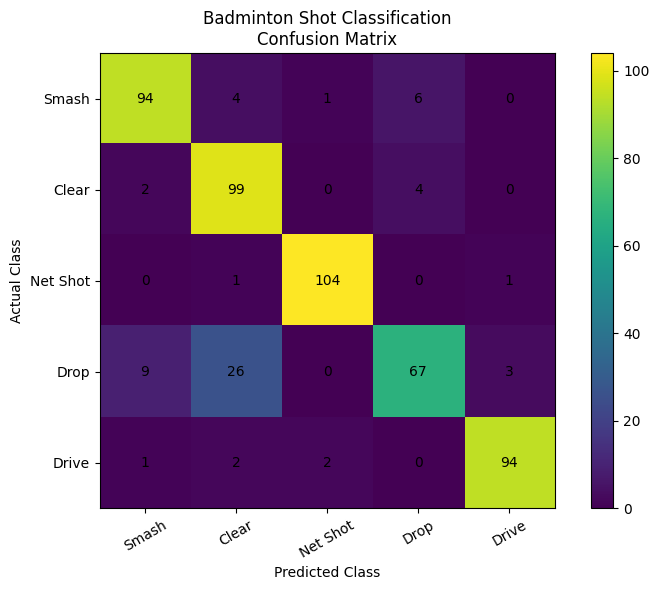

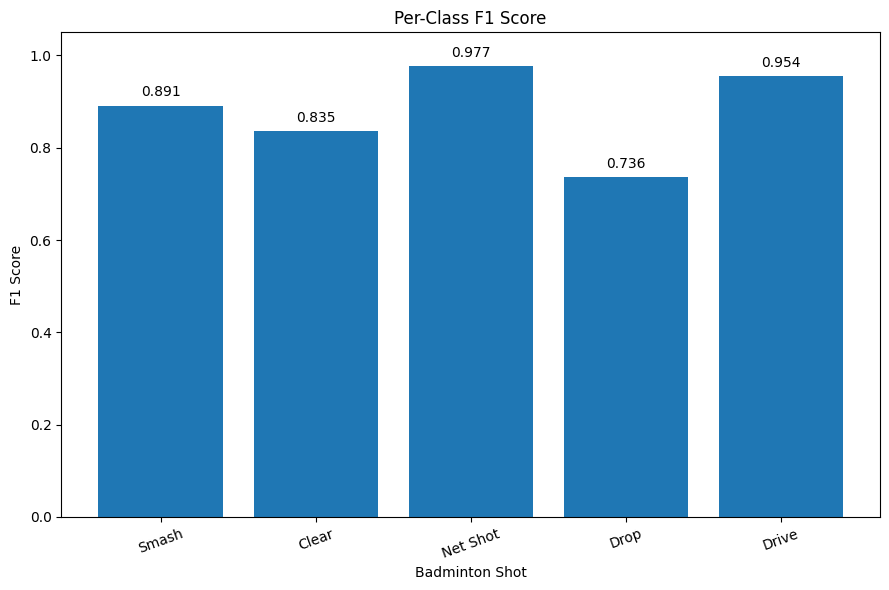


PER-CLASS PERFORMANCE
Smash      | Precision: 0.8868 | Recall: 0.8952 | F1: 0.8910
Clear      | Precision: 0.7500 | Recall: 0.9429 | F1: 0.8354
Net Shot   | Precision: 0.9720 | Recall: 0.9811 | F1: 0.9765
Drop       | Precision: 0.8701 | Recall: 0.6381 | F1: 0.7363
Drive      | Precision: 0.9592 | Recall: 0.9495 | F1: 0.9543

FINAL MODEL
Test Accuracy : 88.08%
Test Macro F1 : 87.87%


In [ ]:
# ==========================================
# FINAL MODEL ANALYSIS + VISUALIZATION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

class_names = [
    "Smash",
    "Clear",
    "Net Shot",
    "Drop",
    "Drive"
]

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title(
    "Badminton Shot Classification\nConfusion Matrix"
)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=30
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

# Write numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()


# ==========================================
# PER-CLASS F1
# ==========================================

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True
)

f1_scores = [
    report[name]["f1-score"]
    for name in class_names
]

precision_scores = [
    report[name]["precision"]
    for name in class_names
]

recall_scores = [
    report[name]["recall"]
    for name in class_names
]


# ==========================================
# F1 SCORE CHART
# ==========================================

plt.figure(figsize=(9, 6))

bars = plt.bar(
    class_names,
    f1_scores
)

plt.ylim(0, 1.05)

plt.ylabel("F1 Score")

plt.xlabel("Badminton Shot")

plt.title(
    "Per-Class F1 Score"
)

for bar, score in zip(bars, f1_scores):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.3f}",
        ha="center"
    )

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()


# ==========================================
# PRINT SUMMARY
# ==========================================

print("\n==========================================")
print("PER-CLASS PERFORMANCE")
print("==========================================")

for i, name in enumerate(class_names):

    print(
        f"{name:10s} | "
        f"Precision: {precision_scores[i]:.4f} | "
        f"Recall: {recall_scores[i]:.4f} | "
        f"F1: {f1_scores[i]:.4f}"
    )

print("\n==========================================")
print("FINAL MODEL")
print("==========================================")

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Macro F1 : {test_f1 * 100:.2f}%")

In [ ]:
# ==========================================
# SAVE FINAL MODEL
# ==========================================

FINAL_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "FINAL_BADMINTON_CNN_LSTM_EPOCH10.pth"
)

torch.save(
    {
        "epoch": checkpoint["epoch"],
        "model_state_dict": model.state_dict(),
        "val_accuracy": checkpoint["val_accuracy"],
        "val_f1": checkpoint["val_f1"],
        "test_accuracy": test_accuracy,
        "test_f1": test_f1,
        "test_loss": test_loss,
        "class_names": [
            "SMASH",
            "CLEAR",
            "NET SHOT",
            "DROP",
            "DRIVE"
        ]
    },
    FINAL_MODEL_PATH
)

print("==========================================")
print("FINAL MODEL SAVED")
print("==========================================")
print(FINAL_MODEL_PATH)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Macro F1: {test_f1 * 100:.2f}%")

FINAL MODEL SAVED
/content/drive/MyDrive/FINAL_BADMINTON_CNN_LSTM_EPOCH10.pth
Test Accuracy: 88.08%
Test Macro F1: 87.87%


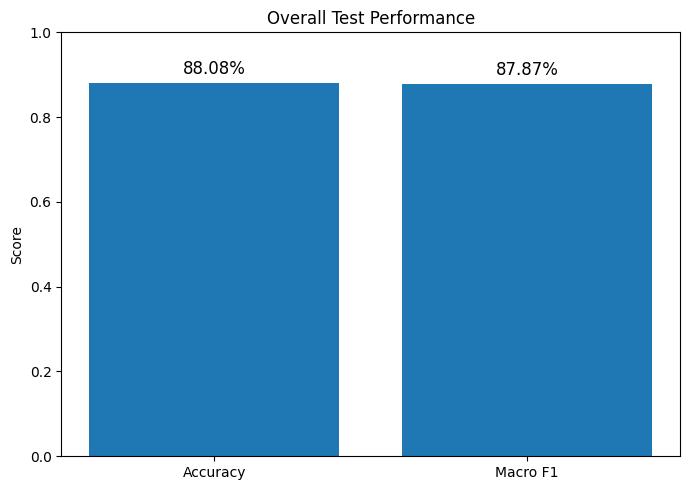

In [ ]:
# ==========================================
# GRAPH 3: OVERALL TEST PERFORMANCE
# ==========================================

import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Macro F1"
]

scores = [
    test_accuracy,
    test_f1
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    metrics,
    scores
)

plt.ylim(0, 1.0)

plt.ylabel("Score")
plt.title("Overall Test Performance")

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score * 100:.2f}%",
        ha="center",
        fontsize=12
    )

plt.tight_layout()
plt.show()

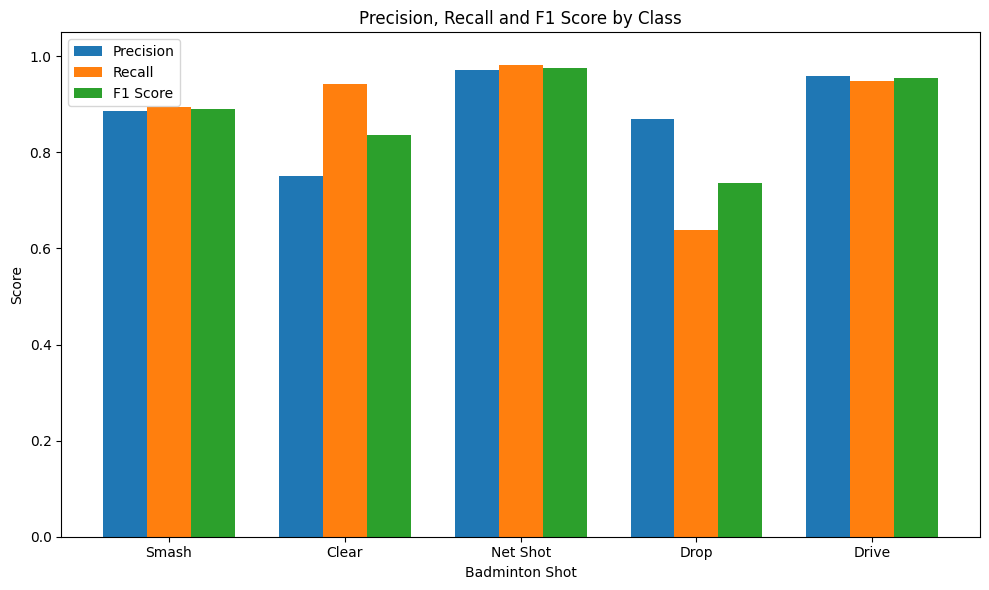

In [ ]:
# ==========================================
# GRAPH 4: PRECISION vs RECALL vs F1
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np

class_names = [
    "Smash",
    "Clear",
    "Net Shot",
    "Drop",
    "Drive"
]

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True
)

precision = [
    report[name]["precision"]
    for name in class_names
]

recall = [
    report[name]["recall"]
    for name in class_names
]

f1 = [
    report[name]["f1-score"]
    for name in class_names
]

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x,
    recall,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    f1,
    width,
    label="F1 Score"
)

plt.ylim(0, 1.05)

plt.xlabel("Badminton Shot")
plt.ylabel("Score")

plt.title(
    "Precision, Recall and F1 Score by Class"
)

plt.xticks(
    x,
    class_names
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# FINAL RESULTS TABLE
# ==========================================

from sklearn.metrics import classification_report
import pandas as pd

class_names = [
    "Smash",
    "Clear",
    "Net Shot",
    "Drop",
    "Drive"
]

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True
)

results_df = pd.DataFrame({
    "Class": class_names,
    "Precision": [
        report[name]["precision"]
        for name in class_names
    ],
    "Recall": [
        report[name]["recall"]
        for name in class_names
    ],
    "F1 Score": [
        report[name]["f1-score"]
        for name in class_names
    ]
})

# Convert to percentage
results_df[
    ["Precision", "Recall", "F1 Score"]
] *= 100

print("==========================================")
print("FINAL CLASS-WISE RESULTS")
print("==========================================")

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}%"
    )
)

print("\n==========================================")
print("OVERALL RESULTS")
print("==========================================")

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Macro F1 : {test_f1 * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

FINAL CLASS-WISE RESULTS
   Class  Precision  Recall  F1 Score
   Smash     88.68%  89.52%    89.10%
   Clear     75.00%  94.29%    83.54%
Net Shot     97.20%  98.11%    97.65%
    Drop     87.01%  63.81%    73.63%
   Drive     95.92%  94.95%    95.43%

OVERALL RESULTS
Test Accuracy : 88.08%
Test Macro F1 : 87.87%
Test Loss     : 0.3468


In [ ]:
# ==========================================
# REMOUNT GOOGLE DRIVE + FIND CHECKPOINT
# ==========================================

from google.colab import drive
import os

drive.mount("/content/drive", force_remount=True)

print("Drive mounted:", os.path.exists("/content/drive"))
print("MyDrive exists:", os.path.exists("/content/drive/MyDrive"))

# Check the 3 checkpoint paths we already know
checkpoint_paths = [
    "/content/drive/MyDrive/badminton_cnn_lstm_best.pth",
    "/content/drive/MyDrive/best_badminton_cnn_lstm.pth",
    "/content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth"
]

print("\nChecking checkpoints:")

for path in checkpoint_paths:
    print(
        os.path.basename(path),
        "->",
        os.path.exists(path)
    )

Mounted at /content/drive
Drive mounted: True
MyDrive exists: True

Checking checkpoints:
badminton_cnn_lstm_best.pth -> True
best_badminton_cnn_lstm.pth -> True
best_badminton_cnn_lstm_model2.pth -> True


In [ ]:
# ==========================================
# INSPECT ALL CHECKPOINTS
# ==========================================

import torch
import os

checkpoint_paths = [
    "/content/drive/MyDrive/badminton_cnn_lstm_best.pth",
    "/content/drive/MyDrive/best_badminton_cnn_lstm.pth",
    "/content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth"
]

print("==========================================")
print("CHECKPOINT INFORMATION")
print("==========================================")

for path in checkpoint_paths:

    print("\nFile:", os.path.basename(path))

    if not os.path.exists(path):
        print("❌ Not found")
        continue

    print("✅ Exists")
    print(
        f"Size: {os.path.getsize(path) / (1024*1024):.2f} MB"
    )

    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=True
    )

    print("Keys:", list(checkpoint.keys()))

    if "epoch" in checkpoint:
        print("Epoch:", checkpoint["epoch"])

    if "val_accuracy" in checkpoint:
        print(
            f"Val Accuracy: "
            f"{checkpoint['val_accuracy'] * 100:.2f}%"
        )

    if "val_f1" in checkpoint:
        print(
            f"Val F1: "
            f"{checkpoint['val_f1'] * 100:.2f}%"
        )

CHECKPOINT INFORMATION

File: badminton_cnn_lstm_best.pth
✅ Exists
Size: 47.74 MB
Keys: ['cnn.conv1.weight', 'cnn.bn1.weight', 'cnn.bn1.bias', 'cnn.bn1.running_mean', 'cnn.bn1.running_var', 'cnn.bn1.num_batches_tracked', 'cnn.layer1.0.conv1.weight', 'cnn.layer1.0.bn1.weight', 'cnn.layer1.0.bn1.bias', 'cnn.layer1.0.bn1.running_mean', 'cnn.layer1.0.bn1.running_var', 'cnn.layer1.0.bn1.num_batches_tracked', 'cnn.layer1.0.conv2.weight', 'cnn.layer1.0.bn2.weight', 'cnn.layer1.0.bn2.bias', 'cnn.layer1.0.bn2.running_mean', 'cnn.layer1.0.bn2.running_var', 'cnn.layer1.0.bn2.num_batches_tracked', 'cnn.layer1.1.conv1.weight', 'cnn.layer1.1.bn1.weight', 'cnn.layer1.1.bn1.bias', 'cnn.layer1.1.bn1.running_mean', 'cnn.layer1.1.bn1.running_var', 'cnn.layer1.1.bn1.num_batches_tracked', 'cnn.layer1.1.conv2.weight', 'cnn.layer1.1.bn2.weight', 'cnn.layer1.1.bn2.bias', 'cnn.layer1.1.bn2.running_mean', 'cnn.layer1.1.bn2.running_var', 'cnn.layer1.1.bn2.num_batches_tracked', 'cnn.layer2.0.conv1.weight', 'cnn.l

In [ ]:
from google.colab import files

MODEL_PATH = "/content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth"

print("Downloading:", MODEL_PATH)

files.download(MODEL_PATH)

Downloading: /content/drive/MyDrive/best_badminton_cnn_lstm_model2.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>